In [10]:
# Import all libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
print("All libraries imported successfully!")

All libraries imported successfully!


In [11]:
# Load the dataset
df=pd.read_csv(r"C:\Users\sanum\Desktop\recommendation_system\ratings.csv", header=None, names=['userId', 'productId', 'rating', 'timestamp'])
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape of dataset: (7824482, 4)

First 5 rows:


,userId,productId,rating,timestamp
0,AKM1MP6P0OYPR,0132793040,5.0,1365811200
1,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
2,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
3,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
4,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200


In [12]:
# Check basic info about the dataset
print("Shape:", df.shape)
print("\nNumber of unique users:", df['userId'].nunique())
print("Number of unique products:", df['productId'].nunique())
print("\nRating statistics:")
df['rating'].describe()

Shape: (7824482, 4)

Number of unique users: 4201696
Number of unique products: 476002

Rating statistics:


count    7.824482e+06
mean     4.012337e+00
std      1.380910e+00
min      1.000000e+00
25%      3.000000e+00
50%      5.000000e+00
75%      5.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

In [13]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values in each column:
userId       0
productId    0
rating       0
timestamp    0
dtype: int64

Duplicate rows: 0


In [15]:
# Drop timestamp column as it is not needed
df = df.drop('timestamp', axis=1)

print("Columns remaining:", df.columns.tolist())
print("New shape:", df.shape)
df.head()

Columns remaining: ['userId', 'productId', 'rating']
New shape: (7824482, 3)


,userId,productId,rating
0,AKM1MP6P0OYPR,0132793040,5.0
1,A2CX7LUOHB2NDG,0321732944,5.0
2,A2NWSAGRHCP8N5,0439886341,1.0
3,A2WNBOD3WNDNKT,0439886341,3.0
4,A1GI0U4ZRJA8WN,0439886341,1.0


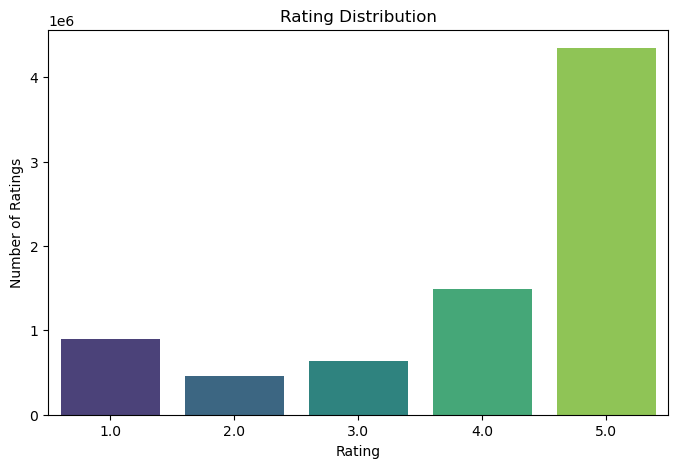

In [16]:
# Rating Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='rating', data=df, palette='viridis')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Number of Ratings')
plt.show()

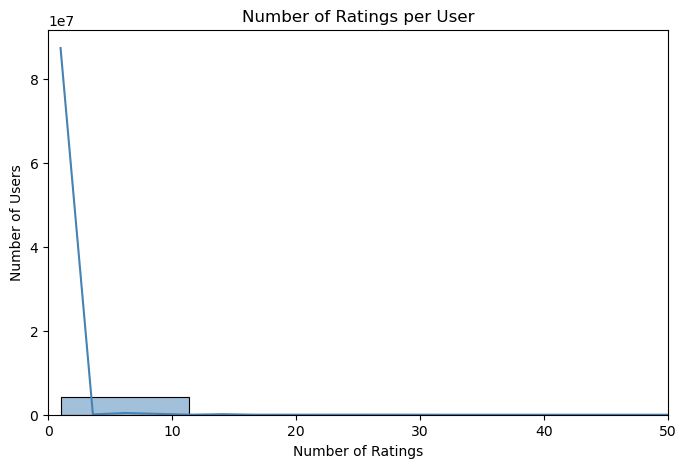

Average ratings per user: 1.86
Median ratings per user: 1.0


In [18]:
# Number of ratings per user
ratings_per_user = df.groupby('userId')['rating'].count()

plt.figure(figsize=(8,5))
sns.histplot(ratings_per_user, bins=50, kde=True, color='steelblue')
plt.title('Number of Ratings per User')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Users')
plt.xlim(0, 50)
plt.show()

print("Average ratings per user:", round(ratings_per_user.mean(), 2))
print("Median ratings per user:", ratings_per_user.median())

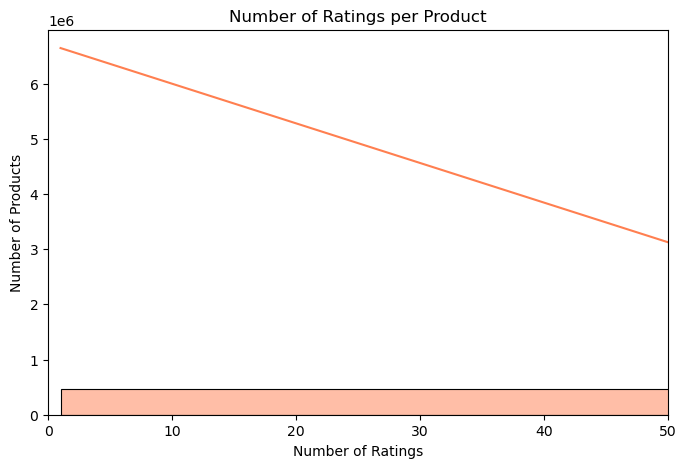

Average ratings per product: 16.44
Median ratings per product: 2.0


In [19]:
# Number of ratings per product
ratings_per_product = df.groupby('productId')['rating'].count()

plt.figure(figsize=(8,5))
sns.histplot(ratings_per_product, bins=50, kde=True, color='coral')
plt.title('Number of Ratings per Product')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Products')
plt.xlim(0, 50)
plt.show()

print("Average ratings per product:", round(ratings_per_product.mean(), 2))
print("Median ratings per product:", ratings_per_product.median())

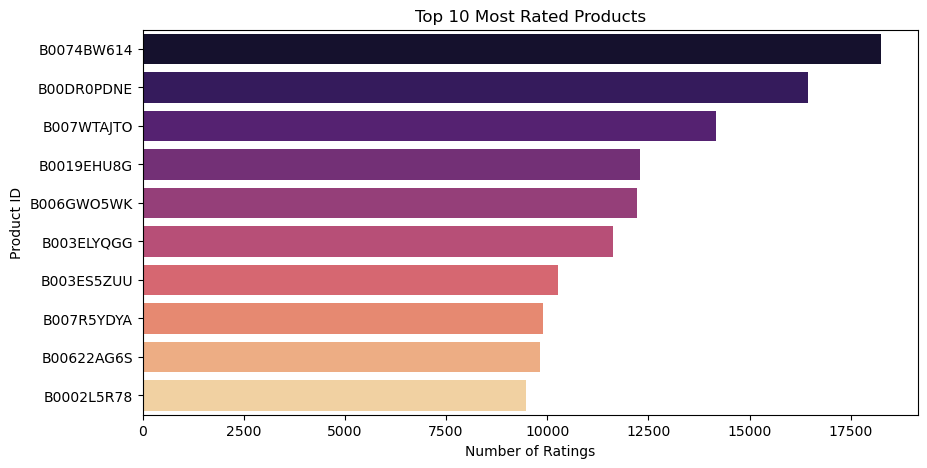

In [21]:
# Top 10 most rated products
top_products = ratings_per_product.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_products.values, y=top_products.index, palette='magma')
plt.title('Top 10 Most Rated Products')
plt.xlabel('Number of Ratings')
plt.ylabel('Product ID')
plt.show()

In [22]:
# calculate sparsity
n_users=df['userId'].nunique()
n_products=df['productId'].nunique()
n_ratings=len(df)

sparsity = 1 - (n_ratings / (n_users * n_products))
print(f"Total possible ratings:{n_users * n_products:,}")
print(f"Actual ratings: {n_ratings:,}")
print(f"Sparsity: {sparsity:.4f} ({sparsity*100:.4f}%)")

Total possible ratings:2,000,015,699,392
Actual ratings: 7,824,482
Sparsity: 1.0000 (99.9996%)
